## SearchRescue search-depth experiment

This notebook studies how unknown search depth changes moral-policy count, community wellbeing, and runtime for several moral configurations.

Data flow:

1. Generate uniquely named configurations and run the planner.
2. Extract repetition-level planner fields into **df**.
3. Aggregate moral-policy counts in **plot_df** and **avg_df**.
4. load policy-level community expectations into **worth_df**.
5. Derive policy wellbeing statistics in **policy_df** and **depth_wellbeing_summary**.
6. Use the reusable plotting helper for wellbeing and runtime comparisons.


In [1]:
from scripts.AbstractExperiments import ExperimentRunner, GenerateConfigs
from EnvironmentBuilder.SearchRescue.Rescue import Rescue
import EnvironmentBuilder.SearchRescue.Drawing as SearchRescueDraw
from scripts.TexTables import SaveDataFrameToTexTemplate
from copy import deepcopy
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})
def latex_config_name(name):
    return "$" + name.replace("^0", "^{0}") + "$"

## Configuration generator

**GenerateTeamConfigs** creates act-utilitarian, separate, fairness, Rawlsian, and combined theory definitions for a team list.

The experiment cell expands them over horizon and unknown-depth values. **configs** is the final list consumed by **ExperimentRunner**; its encoded names preserve community count, horizon, and depth for later extraction.


In [2]:
def GenerateTeamConfigs(teams_:list, name_prefix=None):
    configs = {}
    if name_prefix is None:
        name_prefix = f"{len(teams_)}_"
    # Act-Utilitarianism
    con = {"Theories": [["Add_Util", "Utility", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", "Add_Util"])
    configs[f"{name_prefix}add"] = con

    # Balance
    con = {"Theories": [], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", f"{t}"])
    configs[f"{name_prefix}bal"] = con

    # Fairness
    con = {"Theories": [["Fair", "Fairness", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", ["Fair"]])
    configs[f"{name_prefix}fair"] = con

    # Fairness + Others
    con = {"Theories": [["Fair", "Fairness", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", [f"{t}", "Fair"]])
    configs[f"{name_prefix}fair_bal"] = con

    # Fairness + Act-Utilitarianism
    con = {"Theories": [["Fair", "Fairness", 0], ['Add_Util', 'Utility', 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", ["Fair", "Add_Util"]])
    configs[f"{name_prefix}fair_AU"] = con

    # Rawls
    con = {"Theories":[["Rawls", "Maximin", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", ["Rawls"]])
    configs[f"{name_prefix}rawl"] = con

    # Rawls + Others
    con = {"Theories": [["Rawls", "Maximin", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", [f"{t}", "Rawls"]])
    configs[f"{name_prefix}rawl_bal"] = con

    # Rawls + AU
    con = {"Theories": [["Rawls", "Maximin", 0], ["Add_Util", "Utility", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", ["Rawls", "Add_Util"]])
    configs[f"{name_prefix}rawl_AU"] = con

    return configs

def MakeTeamWeights(teams_):
    p = [2**i for i in range(0, len(teams_))]
    total = sum(p)
    w = [i / total for i in p]
    o = {}
    for t in teams_:
        for i, t in enumerate(teams_):
            o[f"{t}_hosp_success"] = w[i]
    return o

markers = {
    "Separate Theories": "o",
    "Act-Utilitarianism": "s",
    "Fairness": "^",
    "Rawls": "*",
    "Fair + balance": ".",
    "Rawls + balance": "x"
}
colours = {
    "Separate Theories": "blue",
    "Act-Utilitarianism": "black",
    "Fairness": "green",
    "Rawls": "red",
    "Fair + balance": "cyan",
    "Rawls + balance": "magenta",
}

## Generate environments, run the planner, and extract data

**er** manages the Search experiment output. Building environments and running the planner are the expensive stages.

**df** contains one row per planner repetition. The extraction cell removes unused profiling columns, parses communities, Horizon, and unknown_depth from internal names, and replaces those names with readable configuration labels.


In [3]:
env_reps = 1
config_list = []

for horizon_ in range(3, 7):
    for d in range(0, 4):
        teams = ["red", "blue", "green"]
        odds = MakeTeamWeights(teams)

        config_list += GenerateConfigs(
            inputConfigs=GenerateTeamConfigs(
                teams,
                name_prefix=f"c{len(teams)}_h{horizon_}_d{d}"
            ),
            defaultConfig={
                "Horizon": horizon_,
                "Teams": teams,
                "unknown_depth": d,
                "Odds": odds
            }
        )
er = ExperimentRunner(
    "Rescue",
    config_list,
    MoralPlanner_Location="/../../",
    outFolder="Search"
)

In [4]:
d = er.buildEnvironments()

Written Rescue MMMDP with 18 states and theories [{'Name': 'Add_Util', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Search/mdps/c3_h3_d0add_con0.json

Written Rescue MMMDP with 18 states and theories [{'Name': 'red', 'Type': 'Utility', 'Rank': 0}, {'Name': 'blue', 'Type': 'Utility', 'Rank': 0}, {'Name': 'green', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Search/mdps/c3_h3_d0bal_con0.json

Written Rescue MMMDP with 18 states and theories [{'Name': 'Fair', 'Type': 'Fairness', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Search/mdps/c3_h3_d0fair_con0.json

Written Rescue MMMDP with 18 states and theories [{'Name': 'Fair', 'Type': 'Fairness', 'Rank': 0}, {'Name': 'red', 'Type': 'Utility', 'Rank': 0}, {'Name': 'blue', 'Type': 'Utility', 'Rank': 0}, {'Name': 'gree

In [5]:
er.runPlanner(envRepetitions=env_reps)

EXECUTE /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../MPlan/cmake-build-release/MPlan --debug 0 /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Search/mdps/c3_h3_d0add_con0.json /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Search/raw/c3_h3_d0add_con0_rep0.json
THE 2026 MACHINE ETHICS HYPOTHETICAL RETROSPECTION PLANNER (MEHR-PLAN)
JSON file '/home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Search/raw/c3_h3_d0add_con0_rep0.json' created successfully!
EXECUTE /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../MPlan/cmake-build-release/MPlan --debug 0 /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Search/mdps/c3_h3_d0bal_con0.json /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Search/raw/c3_h3_d0bal_con0_rep0.json
THE 2026 MACHINE ETHICS HYPOTHE

In [6]:
er.extractData(1, env_reps)
df = pd.DataFrame(er.data)
df = df.drop(labels=['Conf_rep', 'Theories', 'Considerations', 'CQ1_time', 'CQ2_time', 'Out_time', 'Sol_reduce_time'],
             axis=1)
df = df.replace(["", "N/A", "NA", "nan", "None"], np.nan)

# ------------------------------------------------------------
# Extract environment parameters BEFORE changing Config_name
# ------------------------------------------------------------

df["communities"] = pd.to_numeric(
    df["Config_name"].str.extract(r"^(\d+)", expand=False),
    errors="coerce"
)

df["Horizon"] = pd.to_numeric(
    df["Config_name"].str.extract(r"_h(\d+)", expand=False),
    errors="coerce"
)

df["unknown_depth"] = pd.to_numeric(
    df["Config_name"].str.extract(r"_d(\d+)", expand=False),
    errors="coerce"
)

# ------------------------------------------------------------
# Convert configuration names to readable labels
# ------------------------------------------------------------

df["Config_name"] = np.select(
    [
        df["Config_name"].str.contains("fair_bal", case=False, na=False),
        df["Config_name"].str.contains("fair_AU", case=False, na=False),
        df["Config_name"].str.contains("rawl_bal", case=False, na=False),
        df["Config_name"].str.contains("rawl_AU", case=False, na=False),
        df["Config_name"].str.contains("add", case=False, na=False),
        df["Config_name"].str.contains("bal", case=False, na=False),
        df["Config_name"].str.contains("fair", case=False, na=False),
        df["Config_name"].str.contains("rawl", case=False, na=False),
    ],
    [
        "Fair + Separate",
        "Fair + AU",
        "Rawls + Separate",
        "Rawls + AU",
        "Act-Utilitarianism",
        "Separate Theories",
        "Fairness",
        "Rawls",
    ],
    default=df["Config_name"]
)

df.head(500)

,Config_name,Env_rep,Total_time,Heuristic_time,Plan_time,Sol_time,Mehr_time,Expanded_states,BSG_states,Average_histories,...,Min_non_accept,Num_of_min_non_accept,Num_of_sols,Total_Attacks,Total_reachable_policies,blue:wellbeing,green:wellbeing,red:wellbeing,communities,unknown_depth
0,Act-Utilitarianism,0,101,10,31,59,1,16,18,3,...,0.000000,1,3,4,21,0,1.1429,0,NaN,0
1,Separate Theories,0,96,9,30,55,2,16,18,3,...,2.000000,3,3,18,21,0,1.1429,0,NaN,0
2,Fairness,0,103,9,31,60,3,16,18,3,...,0.000000,1,3,4,21,0,0,0.2857,NaN,0
3,Fair + Separate,0,100,9,30,58,3,16,18,3,...,2.000000,1,3,22,21,0,0,0.2857,NaN,0
4,Fair + AU,0,93,7,23,61,2,16,18,3,...,0.816327,1,3,8,21,0,1.1429,0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,Fair + Separate,0,112064,81,103754,4475,3754,138,178,13,...,2.814066,1,101,5283,8205220811478,1.4286,0,0,NaN,3
124,Fair + AU,0,122571,97,114635,3729,4110,138,178,13,...,0.750000,1,101,2281,8205220811478,1.1488,1.125,1.1488,NaN,3
125,Rawls,0,118471,136,105506,3914,8915,138,178,13,...,0.000000,1,101,2336,8205220811478,1.1488,1.1726,1.1369,NaN,3
126,Rawls + Separate,0,122855,111,107712,5507,9525,138,178,13,...,2.777778,1,101,6331,8205220811478,1.125,1.125,1.1607,NaN,3


## Moral-policy count by unknown depth

**plot_df** is a filtered copy of repetition-level **df**.

**avg_df** averages Num_of_min_non_accept for each Config_name and unknown_depth. The two plot panels compare fairness-based and Rawlsian families while keeping a shared axis and explicit legend order.


In [ ]:
configurations = [
    "Act-Utilitarianism",
    "Rawls",
    "Fairness",
    "Separate Theories",
    "Fair + Separate",
    "Rawls + Separate",
    "Fair + AU",
    "Rawls + AU",
]
markers = {
    "Separate Theories": "o",
    "Act-Utilitarianism": "s",
    "Fairness": "o",
    "Rawls": "o",
    "Fair + balance": ".",
    "Rawls + balance": "x"
}
colours = {
    "Act-Utilitarianism": "black",
    "Rawls": "black",
    "Fairness": "black",

    "Separate Theories": "blue",
    "Fair + Separate": "green",
    "Fair + AU": "cyan",
    "Rawls + Separate": "red",
    "Rawls + AU": "hotpink",
}
opacity = {
    "Act-Utilitarianism": 0.1,
    "Rawls": 0.1,
    "Fairness": 0.1,

    "Separate Theories": 0.5,
    "Fair + Separate": 0.5,
    "Fair + AU": 0.5,
    "Rawls + Separate": 0.5,
    "Rawls + AU": 0.5,
}
# Choose which configurations appear in each panel
configuration_groups = {
    "Fairness": [
        "Act-Utilitarianism",
        "Fairness",
        "Fair + AU",
        "Fair + Separate",
        "Separate Theories",
            
    ],
    "Rawlsian": [
        "Act-Utilitarianism",
        "Rawls",
        "Rawls + AU",
        "Rawls + Separate",
        "Separate Theories",
    ],
}

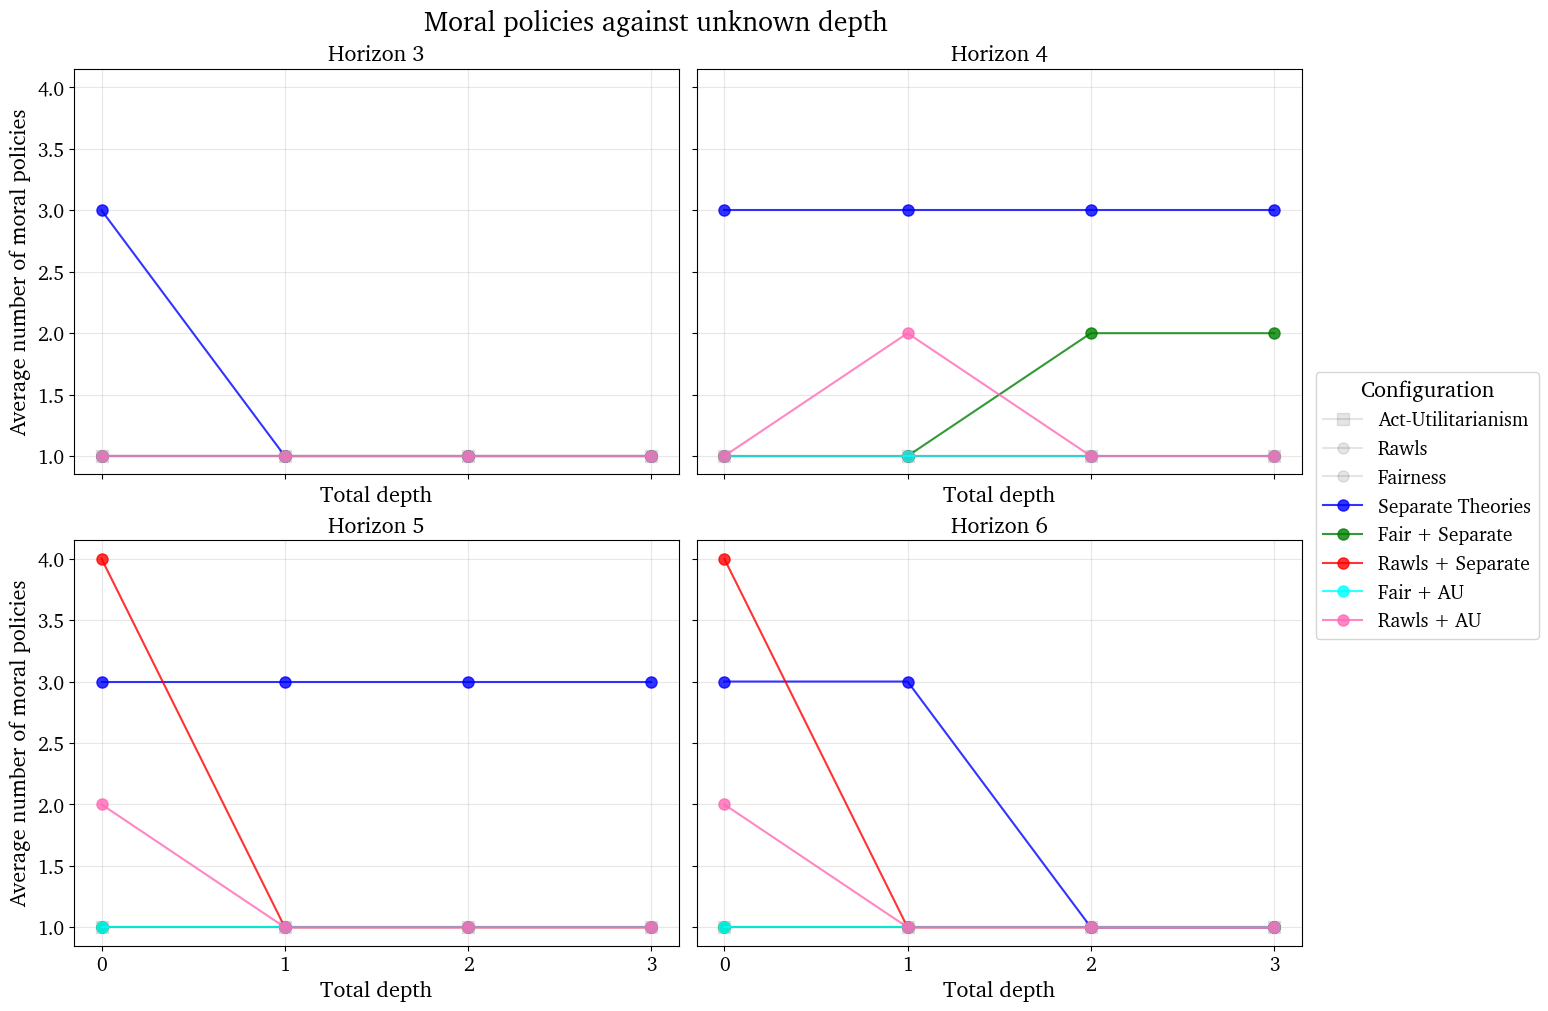

In [8]:
import math
import matplotlib.pyplot as plt


def PlotTheThing(
    plot_df,
    horizons,
    title="Average moral policies against unknown depth",
    file_out=None,
):
    plot_df = plot_df[plot_df["Config_name"].isin(configurations)].copy()
    plot_df = plot_df[plot_df["Horizon"].isin(horizons)]

    avg_df = (
        plot_df
        .groupby(
            ["Horizon", "Config_name", "unknown_depth"],
            as_index=False,
        )["Num_of_min_non_accept"]
        .mean()
        .sort_values(
            ["Horizon", "Config_name", "unknown_depth"]
        )
    )

    # Layout:
    # 1 horizon  -> 1x1
    # 2 horizons -> 1x2
    # 3 horizons -> 1x3
    # 4 horizons -> 2x2
    # >4         -> up to 3 columns
    if len(horizons) <= 3:
        nrows = 1
        ncols = len(horizons)
    elif len(horizons) == 4:
        nrows = 2
        ncols = 2
    else:
        ncols = 3
        nrows = math.ceil(len(horizons) / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(6.5 * ncols, 5 * nrows),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    # Always turn axes into a flat list
    axes = np.atleast_1d(axes).flatten()

    for ax, horizon in zip(axes, horizons):
        horizon_df = avg_df[avg_df["Horizon"] == horizon]

        # Explicitly iterate over configurations so plot and legend
        # order exactly match the configurations list.
        for config in configurations:
            group = horizon_df[
                horizon_df["Config_name"] == config
            ].sort_values("unknown_depth")

            if group.empty:
                continue

            ax.plot(
                group["unknown_depth"],
                group["Num_of_min_non_accept"],
                marker=markers.get(config, "o"),
                markersize=8,
                alpha=opacity.get(config, 0.8),
                color=colours[config],
                label=config,
            )

        ax.set_title(f"Horizon {horizon}")
        ax.set_xlabel("Total depth")
        ax.grid(True, alpha=0.3)

        x_ticks = sorted(horizon_df["unknown_depth"].dropna().unique())

        ax.set_xticks(x_ticks)
        ax.set_xticklabels([f"{int(x)}" for x in x_ticks])

    # Remove unused panels if the grid has more axes than horizons
    for ax in axes[len(horizons):]:
        ax.remove()

    # Y-axis labels on the left-hand plots
    for i, ax in enumerate(axes[:len(horizons)]):
        if i % ncols == 0:
            ax.set_ylabel("Average number of moral policies")

    # Construct the legend explicitly so its order is always exactly
    # the same as the configurations list.
    handles_by_label = {}

    for ax in axes[:len(horizons)]:
        handles, labels = ax.get_legend_handles_labels()

        for handle, label in zip(handles, labels):
            handles_by_label[label] = handle

    legend_labels = [
        config
        for config in configurations
        if config in handles_by_label
    ]

    legend_handles = [
        handles_by_label[config]
        for config in legend_labels
    ]

    fig.legend(
        legend_handles,
        legend_labels,
        title="Configuration",
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
    )

    fig.suptitle(title, fontsize=20)

    if file_out is not None:
        plt.savefig(file_out, bbox_inches="tight")
    plt.show()

plot_df = df.reset_index().copy()
PlotTheThing(plot_df, horizons=[3,4,5,6], title="Moral policies against unknown depth", file_out=f"{er.figuresFolder}/policies_v_depth.png")

## Community wellbeing for individual policies

**worth_df** comes from **er.GetWorthData** and contains one row per returned policy. Community expectation columns end in :wellbeing; identifier columns include Config_name, Horizon, communities, unknown_depth, and repetition/policy metadata.

Internal configuration names are parsed before being replaced with readable labels.


In [11]:
cols = [f"{t}:wellbeing" for t in teams]
worth_df = pd.DataFrame(er.GetWorthData(worth_tags=[f"{t}:wellbeing" for t in teams], envRepetitions=env_reps))
for t in cols:
    worth_df[t] = pd.to_numeric(worth_df[t])
worth_df = worth_df.drop(columns=["Conf_rep"])
worth_df = worth_df.replace(["", "N/A", "NA", "nan", "None"], np.nan)

worth_df["communities"] = pd.to_numeric(
    worth_df["Config_name"].str.extract(r"^(\d+)", expand=False),
    errors="coerce"
)

worth_df["Horizon"] = pd.to_numeric(
    worth_df["Config_name"].str.extract(r"_h(\d+)", expand=False),
    errors="coerce"
)

worth_df["unknown_depth"] = pd.to_numeric(
    worth_df["Config_name"].str.extract(r"_d(\d+)", expand=False),
    errors="coerce"
)

worth_df["Config_name"] = np.select(
    [
        worth_df["Config_name"].str.contains("fair_bal", case=False, na=False),
        worth_df["Config_name"].str.contains("fair_AU", case=False, na=False),
        worth_df["Config_name"].str.contains("rawl_bal", case=False, na=False),
        worth_df["Config_name"].str.contains("rawl_AU", case=False, na=False),
        worth_df["Config_name"].str.contains("add", case=False, na=False),
        worth_df["Config_name"].str.contains("bal", case=False, na=False),
        worth_df["Config_name"].str.contains("fair", case=False, na=False),
        worth_df["Config_name"].str.contains("rawl", case=False, na=False),
    ],
    [   
        "Fair + Separate",
        "Fair + AU",
        "Rawls + Separate",
        "Rawls + AU",
        "Act-Utilitarianism",
        "Separate Theories",
        "Fairness",
        "Rawls",
    ],
    default=worth_df["Config_name"]
)
worth_df = worth_df.sort_values(by=['Config_name', 'Horizon', 'unknown_depth'], ascending=[False, True, True])
worth_df


,Config_name,Env_rep,Horizon,Moral_policy_idx,Non-acceptability,nacc_Add_Util,red:wellbeing,blue:wellbeing,green:wellbeing,nacc_red,nacc_blue,nacc_green,nacc_Fair,nacc_Rawls,communities,unknown_depth
1,Separate Theories,0,3,0,2.000000,NaN,0.0000,0.0000,1.1429,1.0,1.000000,0.000000,NaN,NaN,NaN,0
2,Separate Theories,0,3,1,2.000000,NaN,0.0000,0.5714,0.0000,1.0,0.000000,1.000000,NaN,NaN,NaN,0
3,Separate Theories,0,3,2,2.000000,NaN,0.2857,0.0000,0.0000,0.0,1.000000,1.000000,NaN,NaN,NaN,0
11,Separate Theories,0,3,0,1.666667,NaN,0.5000,0.5000,0.5000,0.0,0.833333,0.833333,NaN,NaN,NaN,1
19,Separate Theories,0,3,0,1.666667,NaN,0.5000,0.5000,0.5000,0.0,0.833333,0.833333,NaN,NaN,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,Act-Utilitarianism,0,5,0,0.000000,0.0,0.7976,0.8452,0.9405,NaN,NaN,NaN,NaN,NaN,NaN,3
122,Act-Utilitarianism,0,6,0,0.000000,0.0,0.0000,0.0000,2.8571,NaN,NaN,NaN,NaN,NaN,NaN,0
136,Act-Utilitarianism,0,6,0,0.000000,0.0,0.5000,0.6429,1.7381,NaN,NaN,NaN,NaN,NaN,NaN,1
146,Act-Utilitarianism,0,6,0,0.000000,0.0,0.7619,0.9167,1.3214,NaN,NaN,NaN,NaN,NaN,NaN,2


## Policy-level and depth-level wellbeing summaries

**policy_df** copies **worth_df** and calculates minimum, maximum, mean, and population standard deviation across the available community wellbeing columns for every policy.

**depth_wellbeing_summary** then averages those four policy statistics by Config_name and unknown_depth. It is the compact table used to inspect how wellbeing distribution changes with search depth.


In [12]:
policy_df = worth_df.copy()

wellbeing_cols = [
    column for column in policy_df.columns
    if column.endswith(":wellbeing")
]
if not wellbeing_cols:
    raise ValueError("No community wellbeing columns were found.")

policy_df[wellbeing_cols] = policy_df[wellbeing_cols].apply(
    pd.to_numeric, errors="coerce"
)

metric_columns = {
    "Minimum": "Policy wellbeing minimum",
    "Maximum": "Policy wellbeing maximum",
    "Mean": "Policy wellbeing mean",
    "Standard deviation": "Policy wellbeing standard deviation",
}

policy_df[metric_columns["Minimum"]] = policy_df[wellbeing_cols].min(axis=1, skipna=True)
policy_df[metric_columns["Maximum"]] = policy_df[wellbeing_cols].max(axis=1, skipna=True)
policy_df[metric_columns["Mean"]] = policy_df[wellbeing_cols].mean(axis=1, skipna=True)
policy_df[metric_columns["Standard deviation"]] = policy_df[wellbeing_cols].std(
    axis=1, skipna=True, ddof=0
)

depth_wellbeing_summary = (
    policy_df
    .dropna(subset=["unknown_depth"])
    .groupby(["Config_name", "unknown_depth"], observed=True)[
        list(metric_columns.values())
    ]
    .mean()
    .reset_index()
    .sort_values(["Config_name", "unknown_depth"])
)
depth_wellbeing_summary.round(4)

,Config_name,unknown_depth,Policy wellbeing minimum,Policy wellbeing maximum,Policy wellbeing mean,Policy wellbeing standard deviation
0,Act-Utilitarianism,0,0.0000,2.0000,0.6667,0.9428
1,Act-Utilitarianism,1,0.5178,1.0952,0.7282,0.2605
2,Act-Utilitarianism,2,0.6458,0.9107,0.7530,0.1146
3,Act-Utilitarianism,3,0.6458,0.9107,0.7530,0.1146
4,Fair + AU,0,0.0000,2.0000,0.6667,0.9428
5,Fair + AU,1,0.5178,1.0952,0.7282,0.2605
6,Fair + AU,2,0.6458,0.9107,0.7530,0.1146
7,Fair + AU,3,0.6458,0.9107,0.7530,0.1146
8,Fair + Separate,0,0.0000,0.5000,0.1667,0.2357
9,Fair + Separate,1,0.1250,0.7143,0.3214,0.2778


### Overview: compare depth levels within each wellbeing statistic

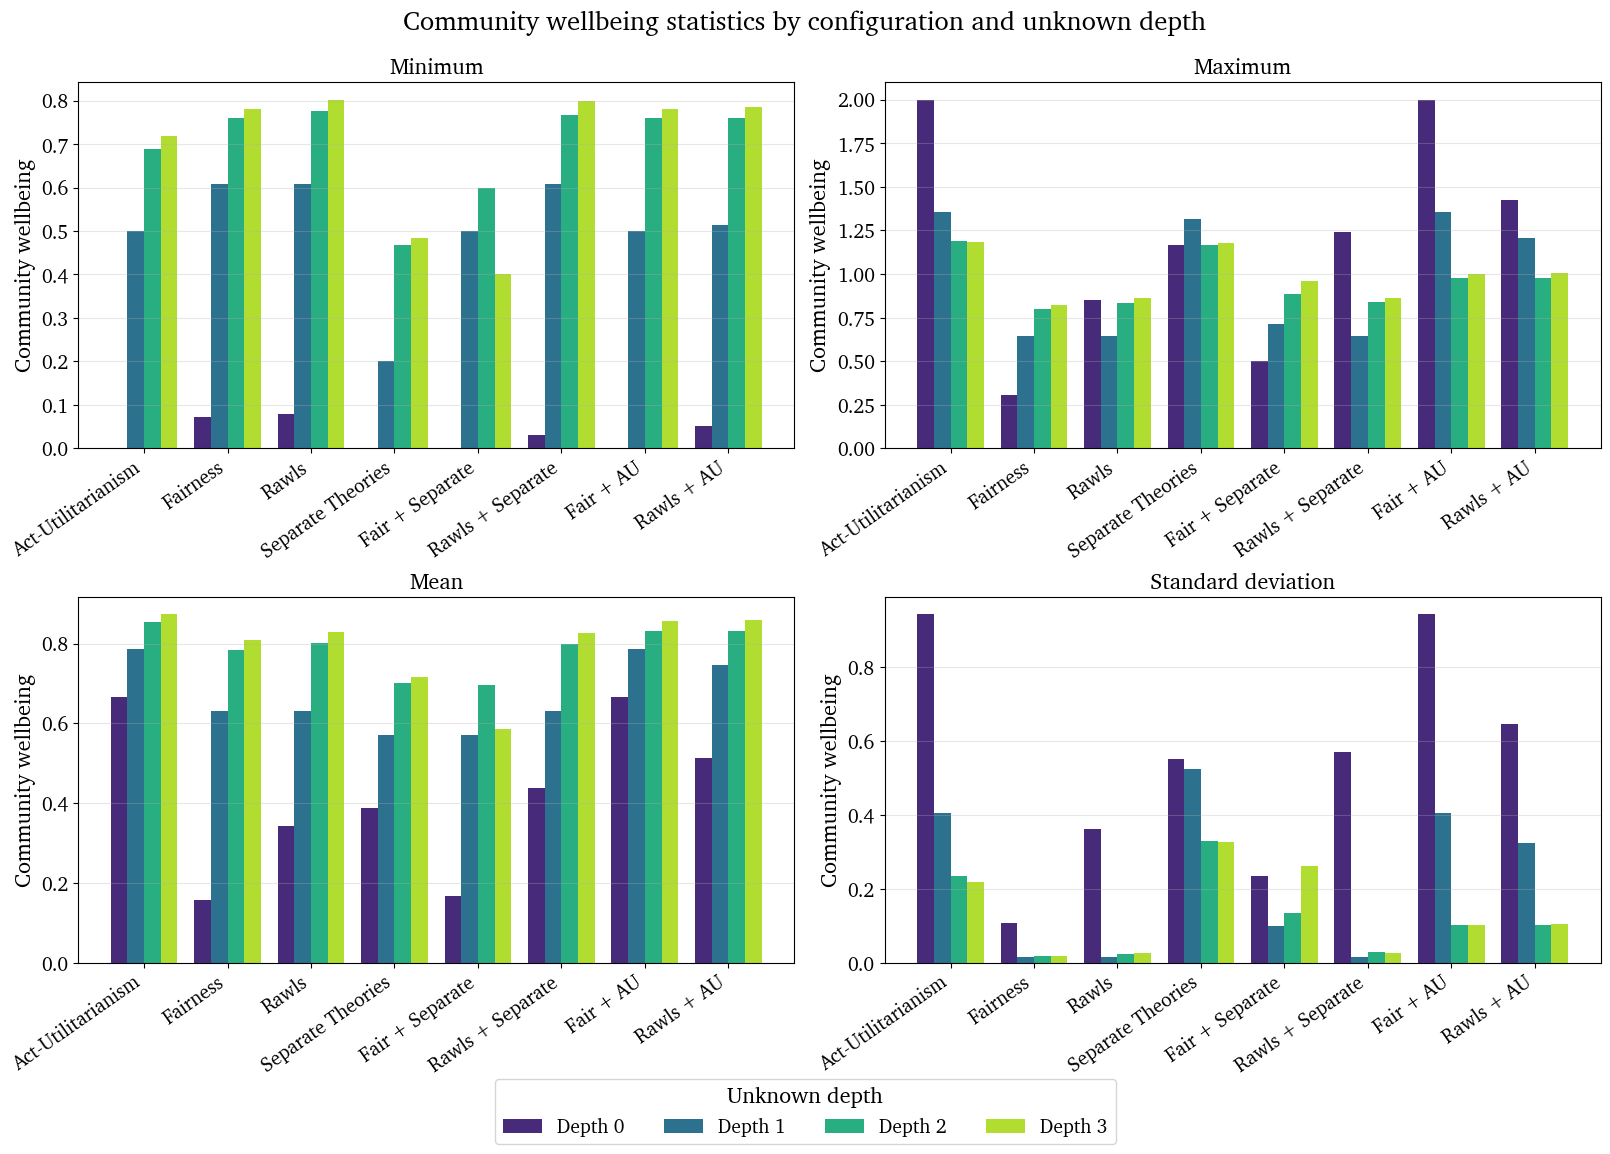

: 

In [ ]:
configuration_order = [
    "Act-Utilitarianism",
    "Fairness",
    "Rawls",
    "Separate Theories",
    "Fair + Separate",
    "Rawls + Separate",
    "Fair + AU",
    "Rawls + AU",
]
configuration_order = [
    config for config in configuration_order
    if config in depth_wellbeing_summary["Config_name"].unique()
]
depth_order = sorted(
    depth_wellbeing_summary["unknown_depth"].dropna().unique()
)
depth_colours = plt.cm.viridis(np.linspace(0.12, 0.88, len(depth_order)))

fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
x = np.arange(len(configuration_order))
bar_width = 0.8 / max(len(depth_order), 1)

for ax, (metric_label, metric_column) in zip(axes.flat, metric_columns.items()):
    pivot = depth_wellbeing_summary.pivot(
        index="Config_name",
        columns="unknown_depth",
        values=metric_column,
    ).reindex(index=configuration_order, columns=depth_order)

    for depth_index, depth in enumerate(depth_order):
        positions = x + (depth_index - (len(depth_order) - 1) / 2) * bar_width
        ax.bar(
            positions,
            pivot[depth].to_numpy(),
            width=bar_width,
            color=depth_colours[depth_index],
            label=f"Depth {int(depth)}",
        )

    ax.set_title(metric_label)
    ax.set_xticks(x)
    ax.set_xticklabels(configuration_order, rotation=35, ha="right")
    ax.set_ylabel("Community wellbeing")
    ax.grid(axis="y", alpha=0.3)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Unknown depth", loc="outside lower center", ncols=len(depth_order))
fig.suptitle("Community wellbeing statistics by configuration and unknown depth", y=1.04)
plt.show()

### Detail: all four statistics for each configuration

Each panel isolates one configuration. Within each unknown-depth group, the four bars show how the distribution of wellbeing between communities changes.

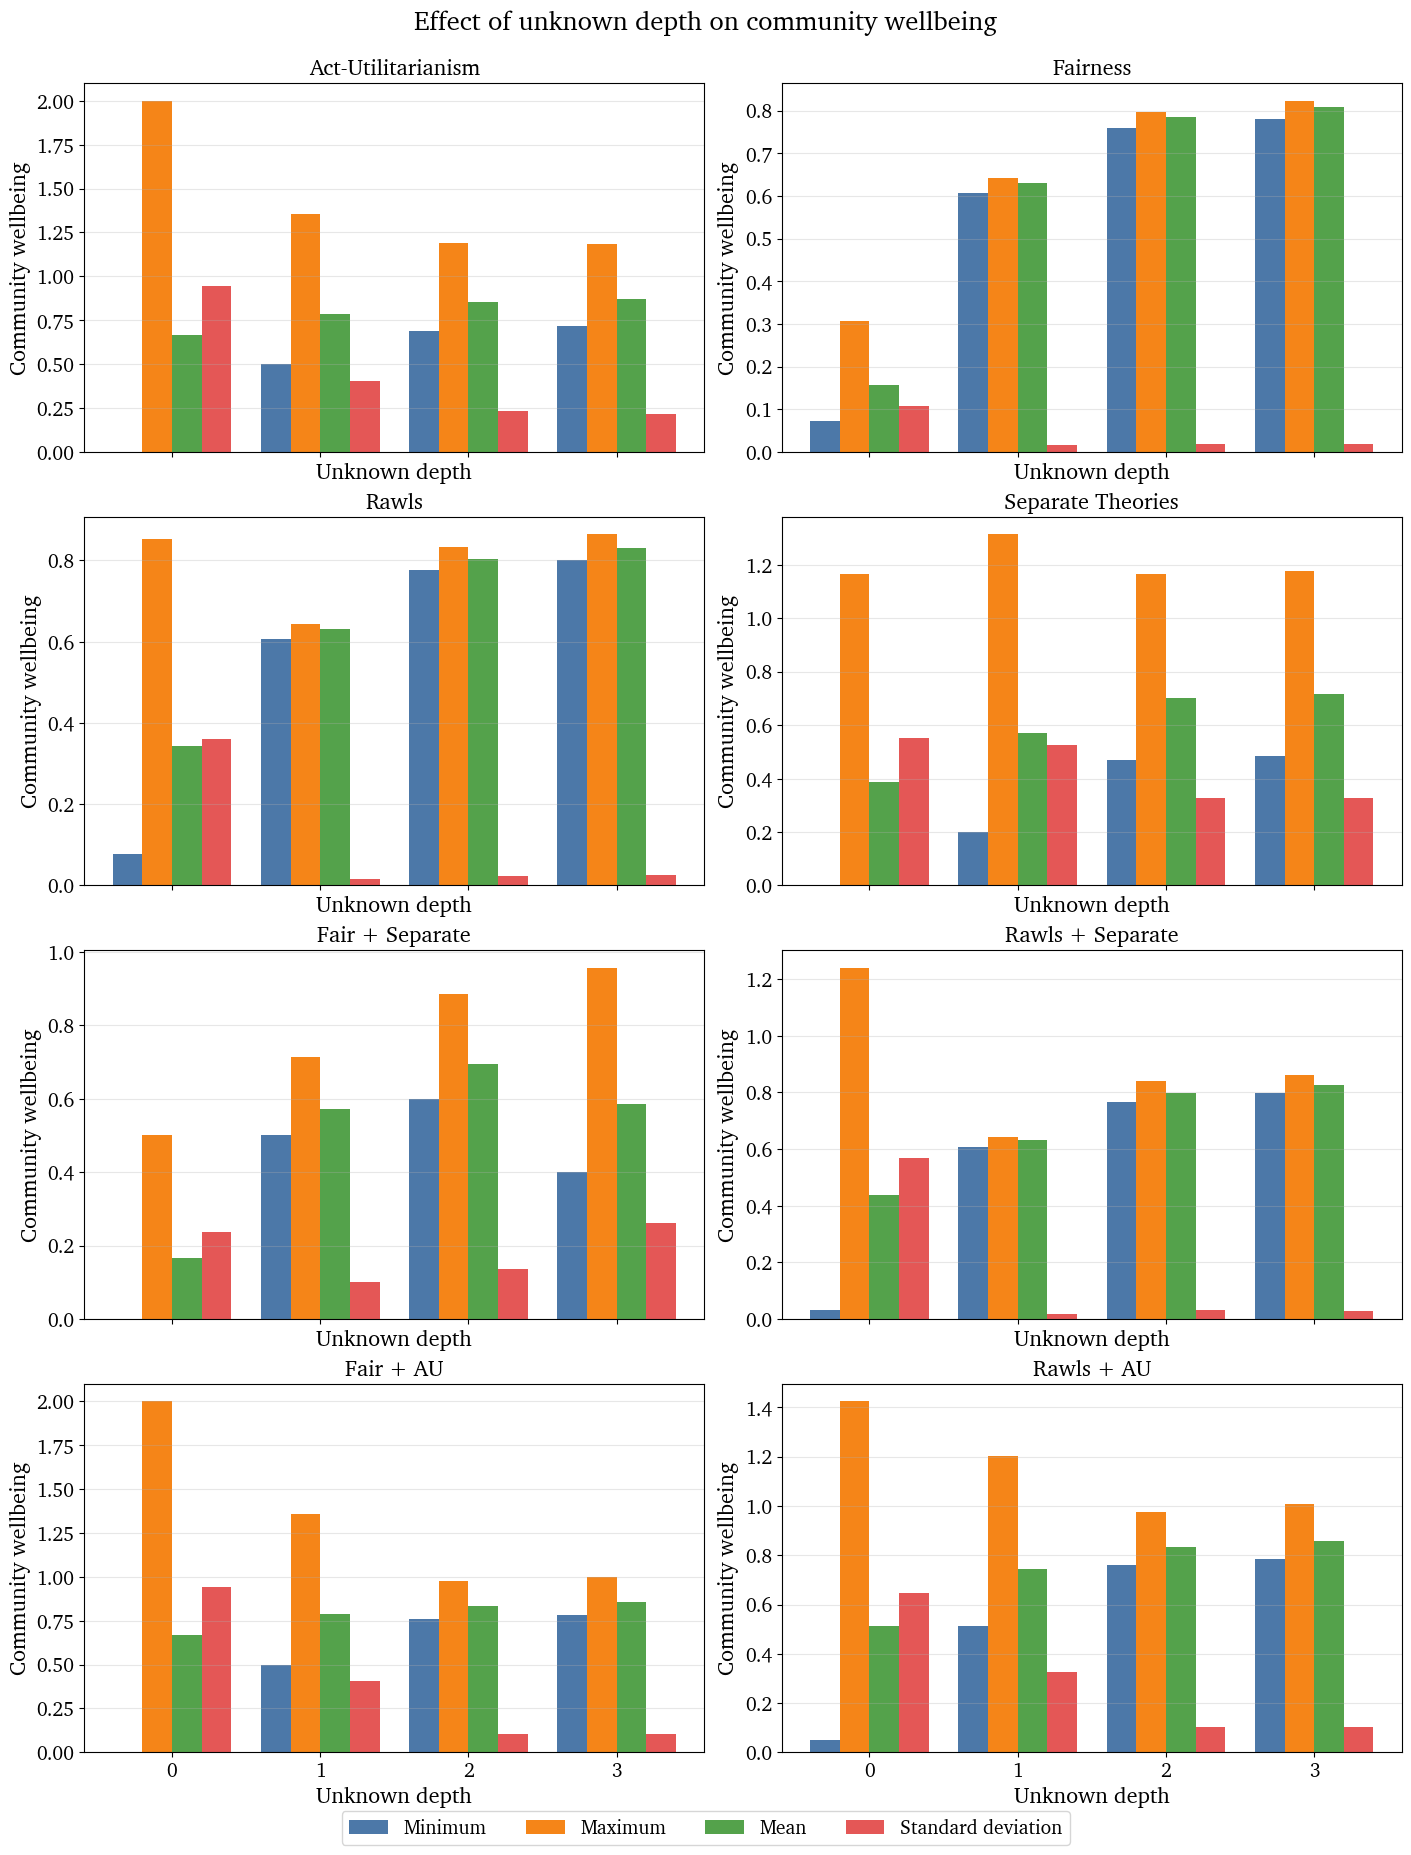

: 

In [ ]:
metric_colours = {
    "Minimum": "#4C78A8",
    "Maximum": "#F58518",
    "Mean": "#54A24B",
    "Standard deviation": "#E45756",
}

ncols = 2
nrows = int(np.ceil(len(configuration_order) / ncols))
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(14, 4.5 * nrows),
    sharex=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes).ravel()
x = np.arange(len(depth_order))
bar_width = 0.8 / len(metric_columns)

for ax, config in zip(axes, configuration_order):
    config_data = (
        depth_wellbeing_summary[depth_wellbeing_summary["Config_name"] == config]
        .set_index("unknown_depth")
        .reindex(depth_order)
    )

    for metric_index, (metric_label, metric_column) in enumerate(metric_columns.items()):
        positions = x + (metric_index - (len(metric_columns) - 1) / 2) * bar_width
        ax.bar(
            positions,
            config_data[metric_column].to_numpy(),
            width=bar_width,
            color=metric_colours[metric_label],
            label=metric_label,
        )

    ax.set_title(config)
    ax.set_xticks(x)
    ax.set_xticklabels([int(depth) for depth in depth_order])
    ax.set_xlabel("Unknown depth")
    ax.set_ylabel("Community wellbeing")
    ax.grid(axis="y", alpha=0.3)

for ax in axes[len(configuration_order):]:
    ax.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=len(metric_columns))
fig.suptitle("Effect of unknown depth on community wellbeing", y=1.025)
plt.savefig(f"{er.figuresFolder}/depth_v_wellbeing.png")
plt.show()

## Reusable configuration and metric plotting function

**plot_configuration_metrics** accepts either raw or pre-aggregated data, resolves metric aliases, applies optional filters, groups observations, and returns the figure, axes, and the exact summary DataFrame used for plotting.

Use **chart_type="line"** for growth curves or **chart_type="bar"** for grouped comparisons. The example below stores its plotted table in **wellbeing_graph_data**.


In [ ]:
WELLBEING_METRIC_ALIASES = {
    "min": "Policy wellbeing minimum",
    "minimum": "Policy wellbeing minimum",
    "max": "Policy wellbeing maximum",
    "maximum": "Policy wellbeing maximum",
    "mean": "Policy wellbeing mean",
    "average": "Policy wellbeing mean",
    "std": "Policy wellbeing standard deviation",
    "standard deviation": "Policy wellbeing standard deviation",
}


def plot_configuration_metrics(
    data,
    configurations,
    independent_variable,
    dependent_variables,
    *,
    aggregation="mean",
    chart_type="line",
    variability=None,
    filters=None,
    log_y=False,
    title=None,
    metric_labels=None,
    figsize=None,
):
    """Plot one or more dependent variables against an independent variable.

    Parameters
    ----------
    data : pandas.DataFrame
        For run-level metrics such as time, pass ``df``. For policy-level
        wellbeing, pass ``depth_wellbeing_summary`` or ``policy_df``.
    configurations : str or sequence of str
        Configuration names to compare.
    independent_variable : str
        Column to place on the x-axis, for example ``"unknown_depth"``.
    dependent_variables : str or sequence of str
        Columns to plot. The aliases min, max, mean, and std select the four
        policy wellbeing statistics created above.
    aggregation : str, default "mean"
        How repeated rows at each configuration/x value are combined.
    chart_type : {"line", "bar"}, default "line"
        Use lines for trends or grouped bars for discrete comparisons.
    variability : {None, "std", "sem"}, default None
        Optional error bars calculated over repeated rows in ``data``.
    filters : mapping, optional
        Values to hold fixed, for example ``{"Horizon": 6}``.
    log_y : bool, default False
        Use a logarithmic y-axis; useful for rapidly growing runtimes.

    Returns
    -------
    fig, axes, summary
        The Matplotlib objects and the aggregated data used in the graph.
    """
    configurations = (
        [configurations]
        if isinstance(configurations, str)
        else list(configurations)
    )
    dependent_variables = (
        [dependent_variables]
        if isinstance(dependent_variables, str)
        else list(dependent_variables)
    )
    if not configurations:
        raise ValueError("Pass at least one configuration.")
    if not dependent_variables:
        raise ValueError("Pass at least one dependent variable/metric.")
    if chart_type not in {"line", "bar"}:
        raise ValueError("chart_type must be either 'line' or 'bar'.")
    if variability not in {None, "std", "sem"}:
        raise ValueError("variability must be None, 'std', or 'sem'.")

    resolved_metrics = []
    for metric in dependent_variables:
        alias = WELLBEING_METRIC_ALIASES.get(str(metric).lower(), metric)
        resolved_metrics.append(alias if alias in data.columns else metric)

    required_columns = {
        "Config_name",
        independent_variable,
        *resolved_metrics,
        *(filters or {}).keys(),
    }
    missing_columns = sorted(required_columns.difference(data.columns))
    if missing_columns:
        raise KeyError(f"Columns not found: {missing_columns}")

    plot_data = data[data["Config_name"].isin(configurations)].copy()
    for column, allowed_values in (filters or {}).items():
        if isinstance(allowed_values, (str, bytes)) or not hasattr(allowed_values, "__iter__"):
            allowed_values = [allowed_values]
        plot_data = plot_data[plot_data[column].isin(allowed_values)]

    numeric_independent = pd.to_numeric(
        plot_data[independent_variable], errors="coerce"
    )
    if numeric_independent.notna().equals(
        plot_data[independent_variable].notna()
    ):
        plot_data[independent_variable] = numeric_independent
    for metric in resolved_metrics:
        plot_data[metric] = pd.to_numeric(plot_data[metric], errors="coerce")

    plot_data = plot_data.dropna(
        subset=["Config_name", independent_variable, *resolved_metrics]
    )
    if plot_data.empty:
        raise ValueError("No rows remain after applying configurations and filters.")

    group_columns = ["Config_name", independent_variable]
    summary = (
        plot_data.groupby(group_columns, observed=True)[resolved_metrics]
        .agg(aggregation)
        .reset_index()
        .sort_values(group_columns)
    )
    error_summary = None
    if variability is not None:
        error_summary = (
            plot_data.groupby(group_columns, observed=True)[resolved_metrics]
            .agg(variability)
            .reset_index()
        )

    metric_count = len(resolved_metrics)
    ncols = min(2, metric_count)
    nrows = int(np.ceil(metric_count / ncols))
    if figsize is None:
        figsize = (7 * ncols, 4.8 * nrows)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        squeeze=False,
        constrained_layout=True,
    )
    axes = axes.ravel()
    x_order = sorted(summary[independent_variable].unique())
    x_positions = np.arange(len(x_order))
    config_colours = plt.cm.tab10(np.linspace(0, 1, len(configurations)))

    for ax, metric in zip(axes, resolved_metrics):
        for config_index, (config, colour) in enumerate(zip(configurations, config_colours)):
            config_data = (
                summary[summary["Config_name"] == config]
                .set_index(independent_variable)
                .reindex(x_order)
            )
            y_values = config_data[metric].to_numpy(dtype=float)
            y_error = None
            if error_summary is not None:
                y_error = (
                    error_summary[error_summary["Config_name"] == config]
                    .set_index(independent_variable)
                    .reindex(x_order)[metric]
                    .to_numpy(dtype=float)
                )

            if chart_type == "bar":
                bar_width = 0.8 / len(configurations)
                positions = (
                    x_positions
                    + (config_index - (len(configurations) - 1) / 2) * bar_width
                )
                ax.bar(
                    positions,
                    y_values,
                    width=bar_width,
                    yerr=y_error,
                    capsize=3 if y_error is not None else 0,
                    color=colour,
                    label=config,
                )
            else:
                ax.errorbar(
                    x_order,
                    y_values,
                    yerr=y_error,
                    marker="o",
                    capsize=3 if y_error is not None else 0,
                    color=colour,
                    label=config,
                )

        if chart_type == "bar":
            ax.set_xticks(x_positions)
            ax.set_xticklabels(x_order)
        ax.set_xlabel(independent_variable.replace("_", " ").title())
        ax.set_ylabel((metric_labels or {}).get(metric, metric.replace("_", " ")))
        ax.set_title((metric_labels or {}).get(metric, metric.replace("_", " ").title()))
        if log_y:
            ax.set_yscale("log")
        ax.grid(axis="y", alpha=0.3)
        ax.legend(title="Configuration")

    for ax in axes[metric_count:]:
        ax.remove()
    if title:
        fig.suptitle(title)
    return fig, axes[:metric_count], summary


: 

### Example: compare minimum and maximum wellbeing

Change `wellbeing_configurations`, the metric aliases, or `chart_type` to generate a different comparison.


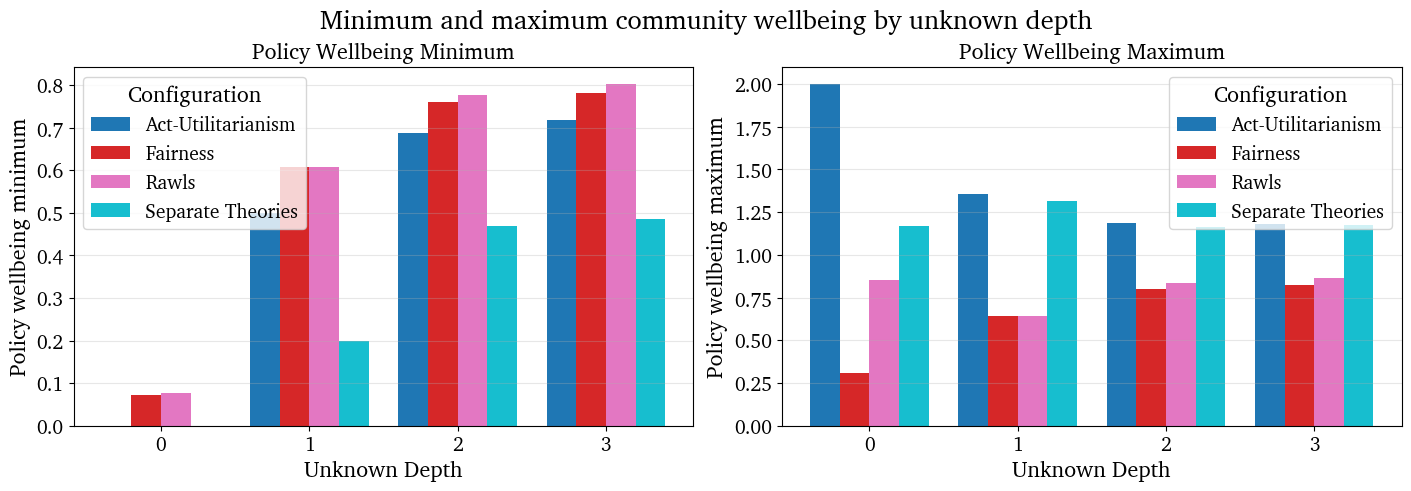

,Config_name,unknown_depth,Policy wellbeing minimum,Policy wellbeing maximum
0,Act-Utilitarianism,0,0.0000,2.0000
1,Act-Utilitarianism,1,0.5000,1.3572
2,Act-Utilitarianism,2,0.6875,1.1875
3,Act-Utilitarianism,3,0.7188,1.1830
4,Fairness,0,0.0729,0.3061
5,Fairness,1,0.6072,0.6428
6,Fairness,2,0.7589,0.7976
7,Fairness,3,0.7812,0.8229
8,Rawls,0,0.0780,0.8520
9,Rawls,1,0.6072,0.6428


: 

: 

: 

: 

In [ ]:
wellbeing_configurations = [
    "Act-Utilitarianism",
    "Fairness",
    "Rawls",
    "Separate Theories",
]

wellbeing_figure, wellbeing_axes, wellbeing_graph_data = plot_configuration_metrics(
    depth_wellbeing_summary,
    configurations=wellbeing_configurations,
    independent_variable="unknown_depth",
    dependent_variables=["min", "max"],
    chart_type="bar",
    title="Minimum and maximum community wellbeing by unknown depth",
)
plt.show()
wellbeing_graph_data.round(4)


## Runtime complexity by unknown depth

This section uses the repetition-level **df**, not **worth_df**. It selects the maximum recorded horizon and plots mean Total_time against unknown_depth on a logarithmic y-axis.

The helper returns **runtime_graph_data**, which contains the grouped values drawn in the figure and can be inspected or exported independently.


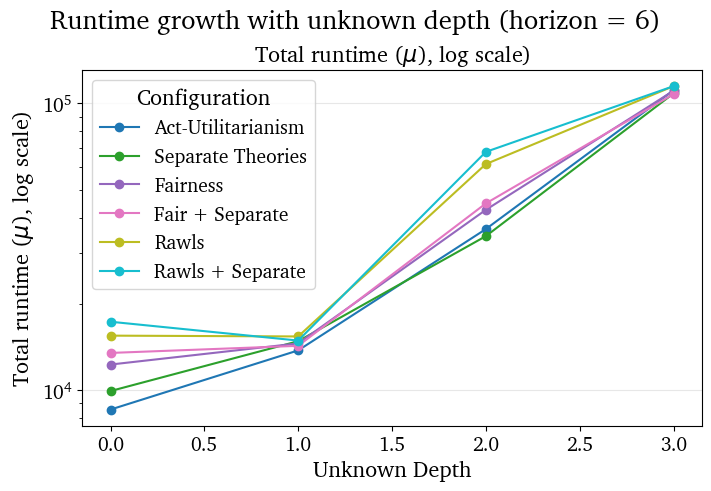

,Config_name,unknown_depth,Total_time
0,Act-Utilitarianism,0,8567.0
1,Act-Utilitarianism,1,13775.0
2,Act-Utilitarianism,2,36479.0
3,Act-Utilitarianism,3,111182.0
4,Fair + Separate,0,13496.0
5,Fair + Separate,1,14289.0
6,Fair + Separate,2,44818.0
7,Fair + Separate,3,107775.0
8,Fairness,0,12295.0
9,Fairness,1,14573.0


: 

In [ ]:
runtime_configurations = [
    "Act-Utilitarianism",
    "Separate Theories",
    "Fairness",
    "Fair + Separate",
    "Rawls",
    "Rawls + Separate",
]
runtime_horizon = int(pd.to_numeric(df["Horizon"], errors="coerce").max())

runtime_figure, runtime_axes, runtime_graph_data = plot_configuration_metrics(
    df,
    configurations=runtime_configurations,
    independent_variable="unknown_depth",
    dependent_variables="Total_time",
    filters={"Horizon": runtime_horizon},
    chart_type="line",
    log_y=True,
    metric_labels={f"Total_time": f"Total runtime ({latex_config_name("\\mu")}), log scale)"},
    title=f"Runtime growth with unknown depth (horizon = {runtime_horizon})",
)
plt.show()
runtime_graph_data.round(2)
